# Unified Photometry

In [1]:
import warnings
warnings.filterwarnings("ignore")
from astropy.table import Table, Column, vstack
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astropy.io import fits
import astropy.units as u
import numpy as np
import pandas as pd
from utils import *
from catalog import *
from photometry import *
from subtraction import *
from photutils.psf import IterativePSFPhotometry
ra, dec = 113.7617,	6.3244
# ra, dec = 149.9134113, -3.3085028
# ra, dec = 149.9015318, -3.3201282
band = 'i'

In [2]:
fits_dir = '/home/liangrd/optical_data/EP260116a/pipeline/LCO/coadd_LCO_i_20260121T135134.876.fits'
fpath = '/home/liangrd/optical_data/EP260116a'
cat_dir = '/home/liangrd/optical_data/EP260116a/ps.csv'

In [3]:
phot = Photometry()
phot.read_image(fits_dir,masklow=None)

Image and WCS loaded successfully.


Matched stars before filtering: 270
After saturation filtering: 257

Zeropoint = 29.177 ± 0.030  (N=178)


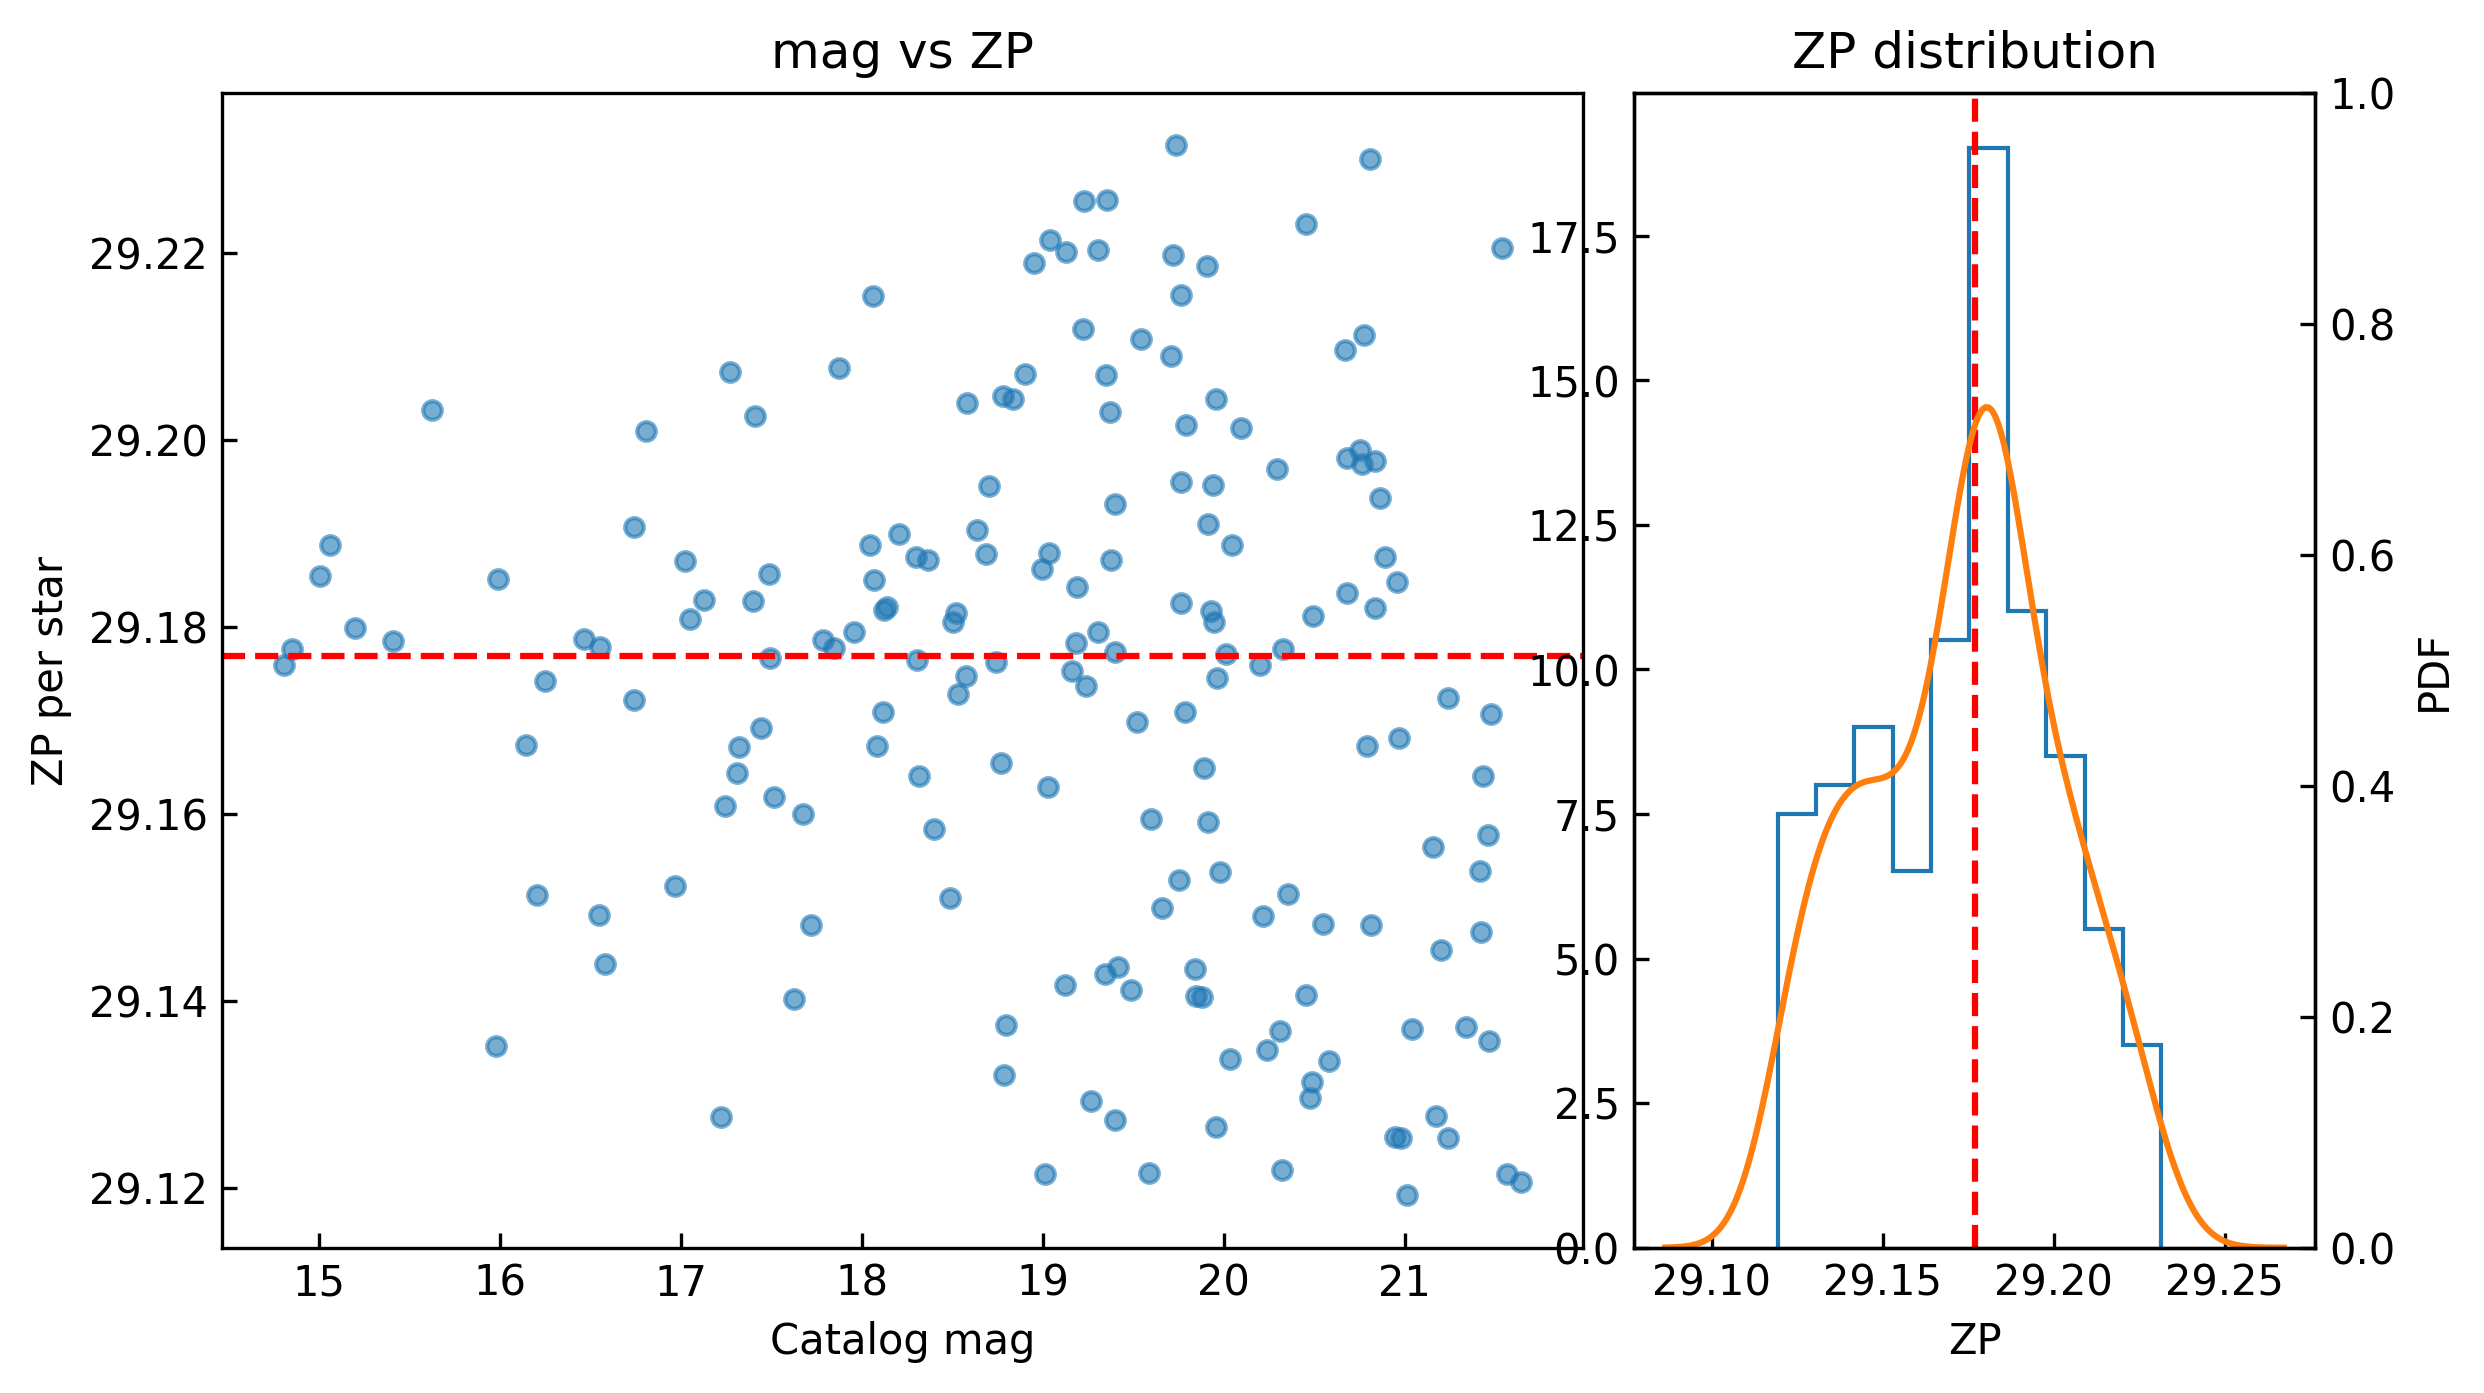

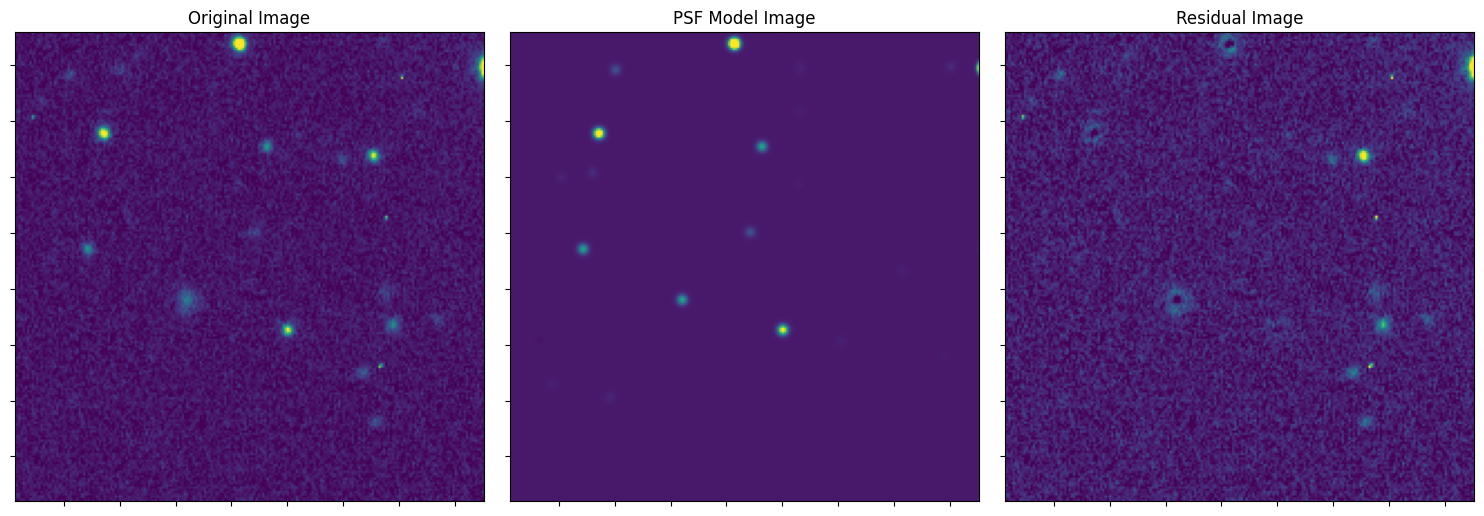

Target not detected → computing upper limit
3-sigma upper limit = 23.509


{'upper_limit': 23.508985138666233}

In [4]:
'PSF Photometry after ZP calibration'

res = phot.psf_photometry(ra=ra,dec=dec,fwhm=3.5,sigma=3.,sigma_clip_val=2.0,cat_dir=cat_dir,mag_col=band,fit_shape=(9,9),forced=False,plot_scale=60)
res

Matched stars before filtering: 105
After saturation filtering: 100

Zeropoint = 28.834 ± 0.047  (N=58)


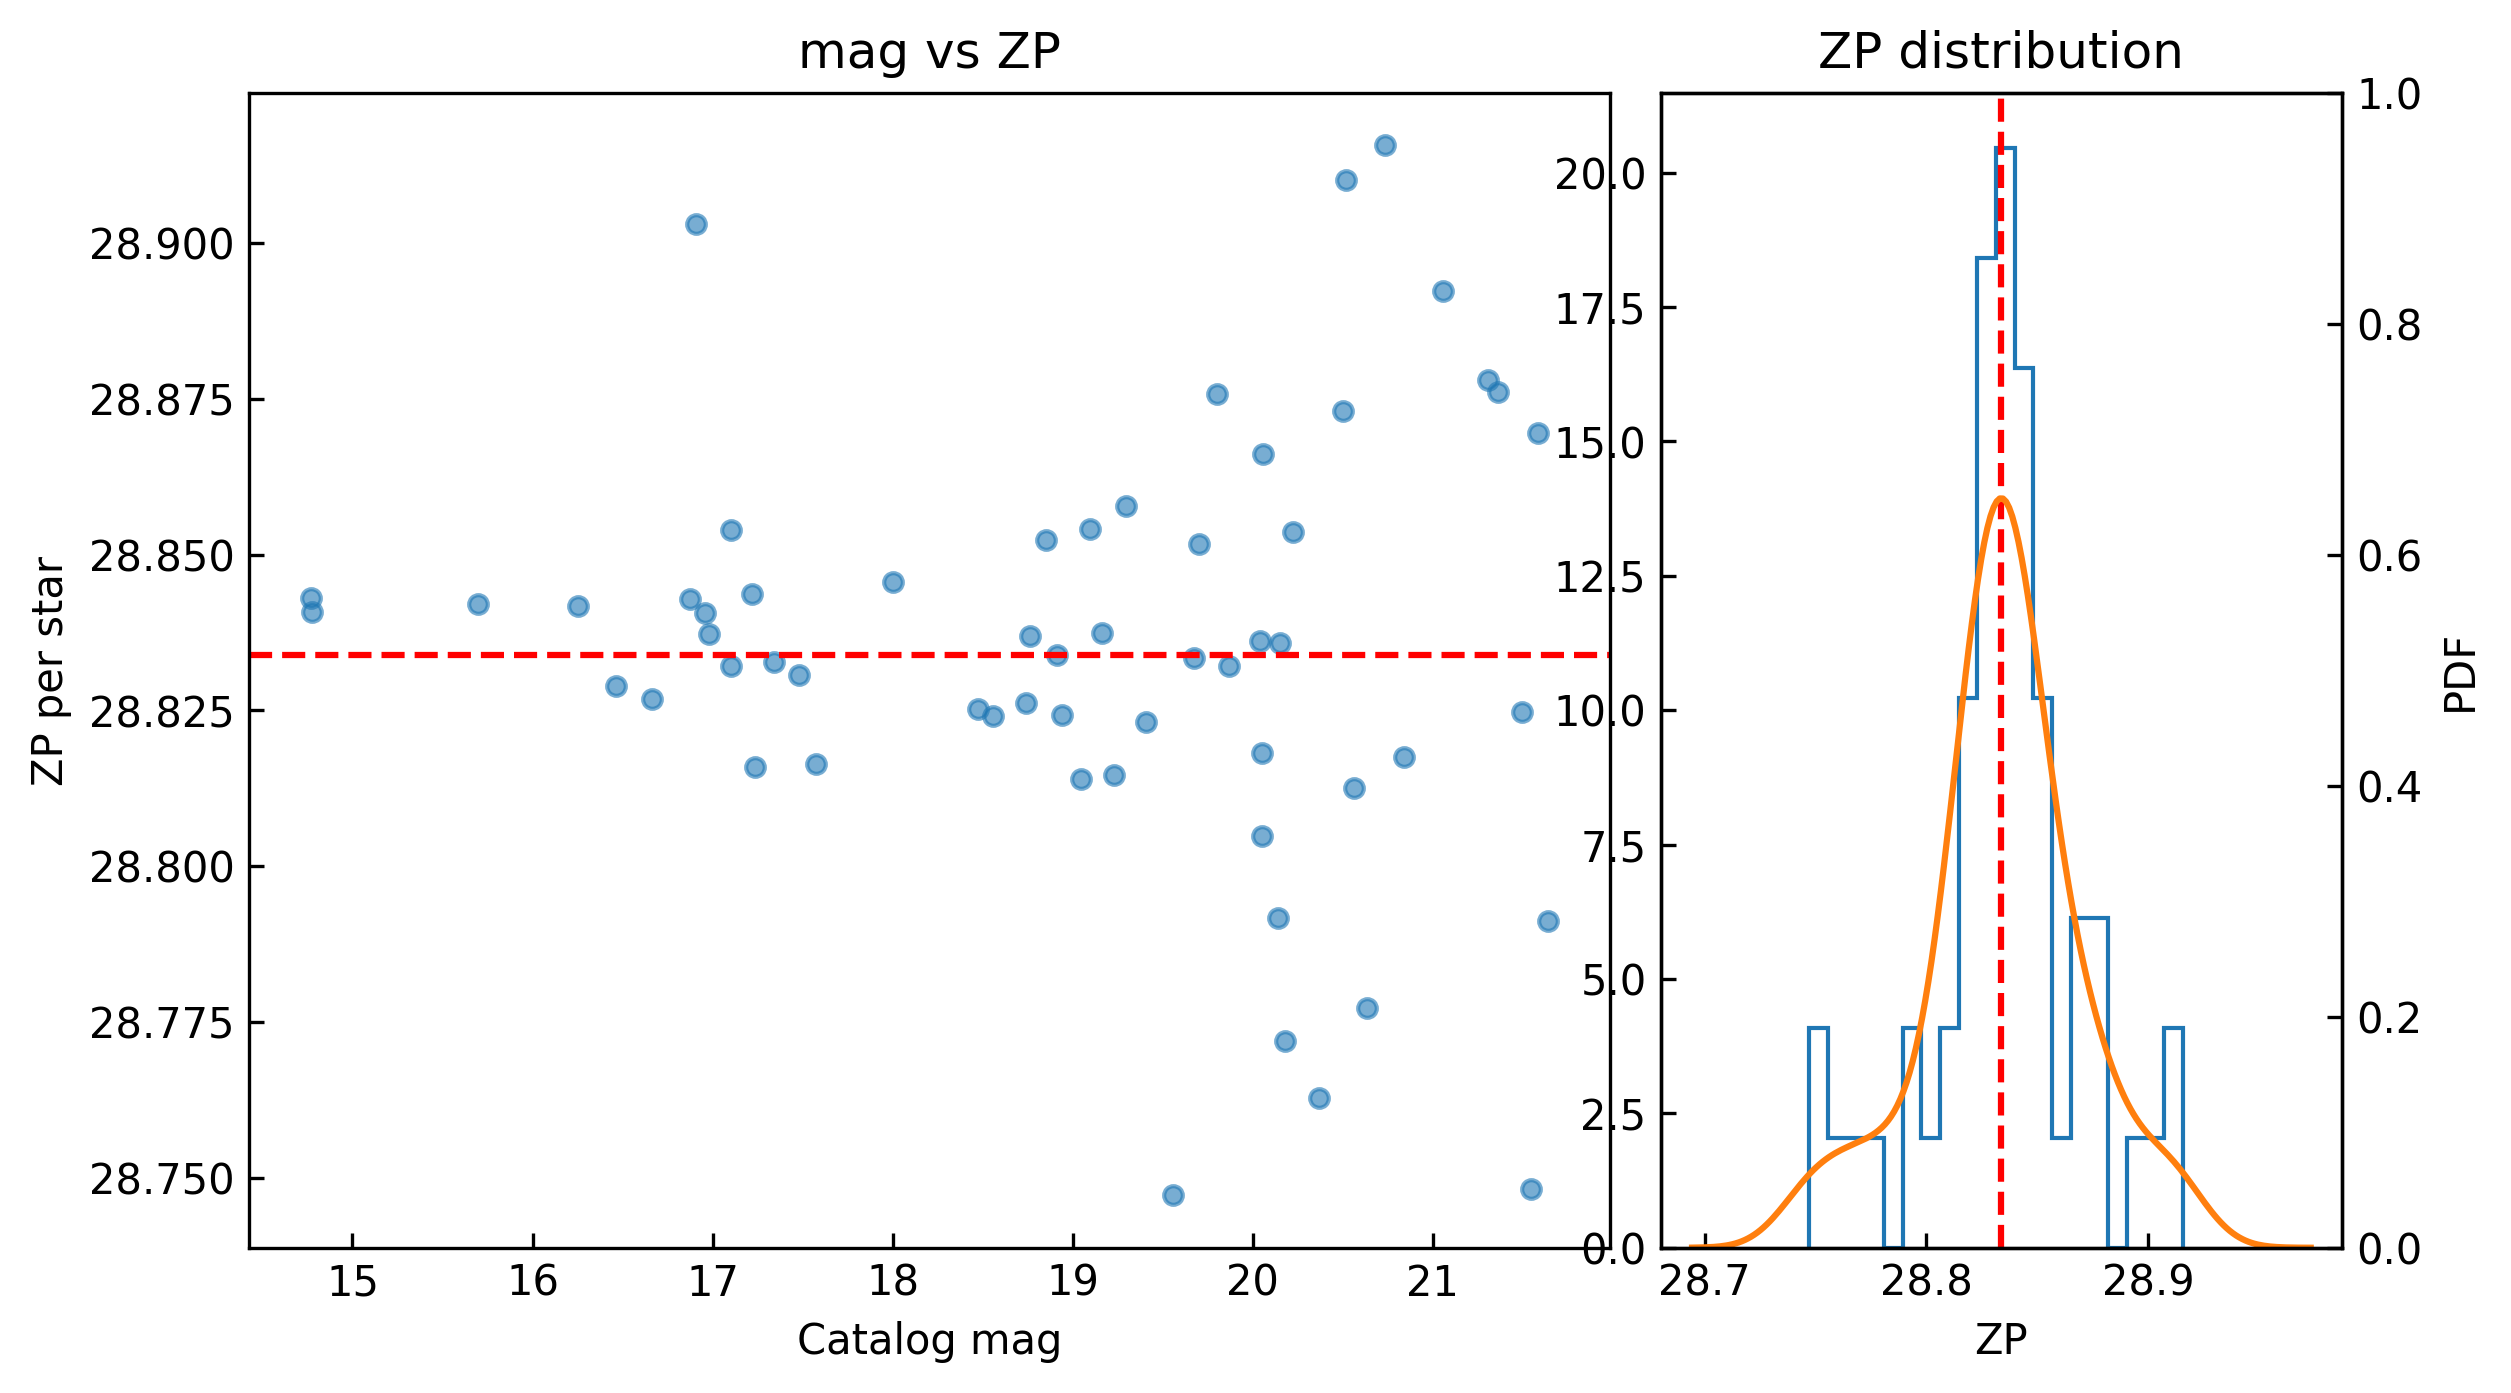

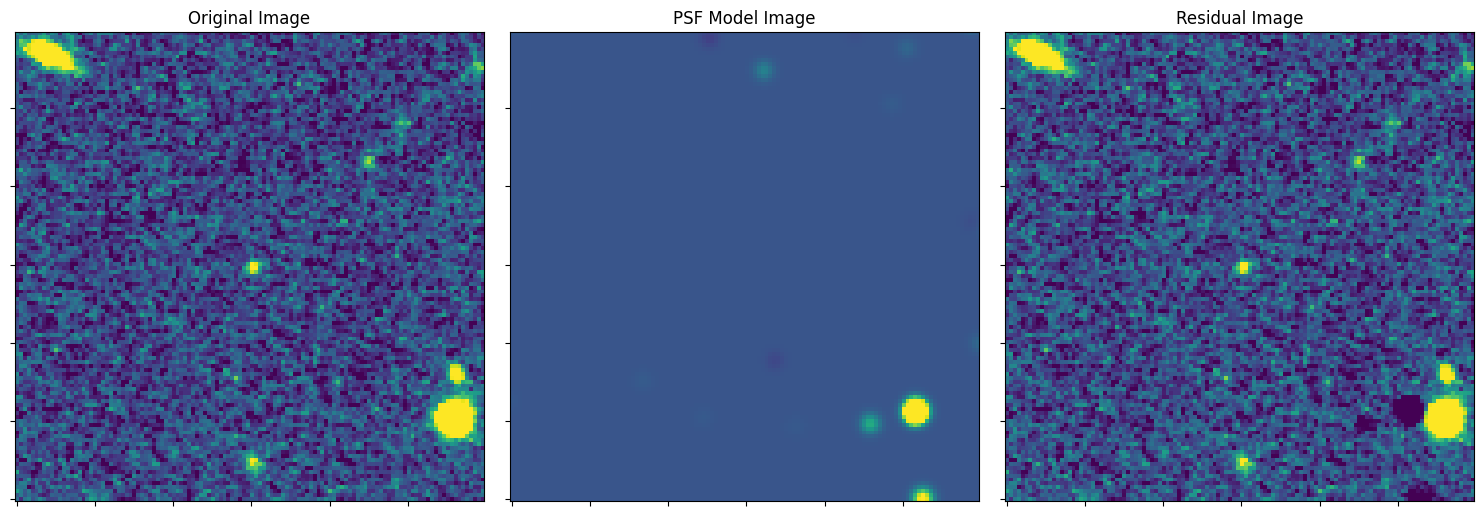

Aperture magnitude = 22.706 ± 0.128


id,xcenter,ycenter,aperture_sum,aperture_sum_err,total_bkg,aperture_sum_bkgsub
int64,float64,float64,float64,float64,float64,float64
1,938.9049514742503,515.4857660614119,265.2963353344678,30.954404039131454,-17.144812357687684,282.4411476921555


In [12]:
phot.aperture_photometry(ra=ra,dec=dec,r_ap=1,r_in=10,r_out=15,cat_dir=cat_dir,sigma=3,fwhm=4.0,mag_col=band,fit_shape=(7,7),forced=True,)

In [8]:
target = SkyCoord(ra,dec,unit='deg')
cat = SkyCoord(phot.cat_df['RA'], phot.cat_df['DEC'], unit='deg')
idx, d2d, d3d = target.match_to_catalog_sky(cat)
phot.cat_df[['RA','DEC','i','i_err']].iloc[idx]

RA       149.901532
DEC       -3.320128
i         20.907600
i_err      0.045399
Name: 390, dtype: float64

## Upper Limits

In [21]:
fits_dir = '/Volumes/T7/Shared_Files/EP/Results/SBO/data/EP240506a_AT2024ofs/EP240506a_TRT/stack/TRT_2025-05-07_Rc.fits.fits'
fpath = '/Volumes/T7/Shared_Files/EP/Results/SBO/data/EP240506a_AT2024ofs/EP240506a_TRT/stack'

In [22]:
phot = Photometry()
phot.read_image(fits_dir)

Image and WCS loaded successfully.


In [23]:
zp_res = phot.compute_zeropoint(ps_dir='/Volumes/T7/Shared_Files/EP/Results/SBO/data/EP240506a_AT2024ofs/EP240506a_TRT/stack/ps.csv',path=fpath,mag_col='i',mag_cut=15,fwhm=7)

Estimated FWHM: 3.8+/-0.2 pixels
Zeropoint: 28.533 ± 0.332 mag (N=201)


In [32]:
phot.estimate_upperlimit(r=5)

23.182308910696744